# AI-Based Yoga Pose Detection System

## Computer Vision + MediaPipe Pose + Artificial Neural Network Based Classification System

### Objective

Build an AI-based yoga pose classification system that detects human body poses from images using MediaPipe Pose landmarks and classifies different yoga poses using Machine Learning and Deep Learning models.
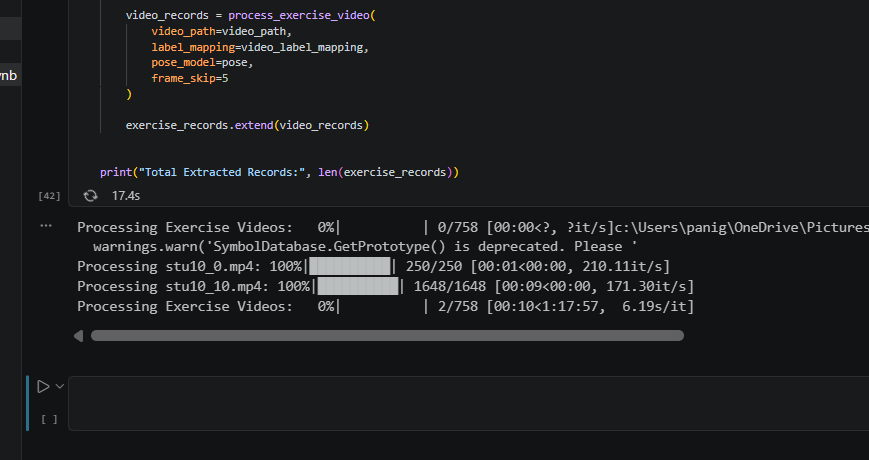

## Import Libraries

In [1]:
# Data Handling
import os
import numpy as np
import pandas as pd

# Image Processing
import cv2
import matplotlib.pyplot as plt

# MediaPipe
import mediapipe as mp

# Path Handling
from pathlib import Path

# Progress Tracking
from tqdm import tqdm

# Display Settings
import warnings
warnings.filterwarnings("ignore")

## Dataset Configuration

In [4]:
# Dataset Paths

YOGA_DATASET_PATH = r"D:\datasets\yoga"


TRAIN_PATH = os.path.join(
    YOGA_DATASET_PATH,
    "train"
)


VALID_PATH = os.path.join(
    YOGA_DATASET_PATH,
    "valid"
)


TEST_PATH = os.path.join(
    YOGA_DATASET_PATH,
    "test"
)



# Image Configuration

IMAGE_SIZE = 224



# MediaPipe Pose Configuration

TOTAL_LANDMARKS = 33


FEATURES_PER_LANDMARK = 4


TOTAL_FEATURES = (
    TOTAL_LANDMARKS 
    * FEATURES_PER_LANDMARK
)



# Display Configuration

print("Dataset Path:", YOGA_DATASET_PATH)

print("Train Path:", TRAIN_PATH)

print("Validation Path:", VALID_PATH)

print("Test Path:", TEST_PATH)

print("Total Pose Features:", TOTAL_FEATURES)

Dataset Path: D:\datasets\yoga
Train Path: D:\datasets\yoga\train
Validation Path: D:\datasets\yoga\valid
Test Path: D:\datasets\yoga\test
Total Pose Features: 132


## Observations

- Yoga dataset paths were successfully configured for train, validation, and test splits.
- The dataset follows a structured folder-based classification format.
- MediaPipe Pose feature configuration was defined successfully.
- A total of 132 pose features were finalized based on:
  
  33 body landmarks × 4 attributes (X, Y, Z, Visibility)

- The project configuration is ready for dataset exploration and feature extraction pipeline development.

## Yoga Dataset Understanding

In [5]:
# Get Yoga Pose Classes from Training Dataset

yoga_classes = [
    folder
    for folder in os.listdir(TRAIN_PATH)
    if os.path.isdir(
        os.path.join(
            TRAIN_PATH,
            folder
        )
    )
]


print("Total Yoga Classes:", len(yoga_classes))

print("\nYoga Classes:")
for idx, cls in enumerate(yoga_classes, start=1):
    print(f"{idx}. {cls}")

Total Yoga Classes: 82

Yoga Classes:
1. Akarna_Dhanurasana
2. Bharadvajas_Twist_pose_or_Bharadvajasana_I_
3. Boat_Pose_or_Paripurna_Navasana_
4. Bound_Angle_Pose_or_Baddha_Konasana_
5. Bow_Pose_or_Dhanurasana_
6. Bridge_Pose_or_Setu_Bandha_Sarvangasana_
7. Camel_Pose_or_Ustrasana_
8. Cat_Cow_Pose_or_Marjaryasana_
9. Chair_Pose_or_Utkatasana_
10. Child_Pose_or_Balasana_
11. Cobra_Pose_or_Bhujangasana_
12. Cockerel_Pose
13. Corpse_Pose_or_Savasana_
14. Cow_Face_Pose_or_Gomukhasana_
15. Crane_(Crow)_Pose_or_Bakasana_
16. Dolphin_Plank_Pose_or_Makara_Adho_Mukha_Svanasana_
17. Dolphin_Pose_or_Ardha_Pincha_Mayurasana_
18. Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_
19. Eagle_Pose_or_Garudasana_
20. Eight-Angle_Pose_or_Astavakrasana_
21. Extended_Puppy_Pose_or_Uttana_Shishosana_
22. Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_
23. Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_
24. Feathered_Peacock_Pose_or_Pincha_Mayurasana_
25. Firefly_Pose_or_Tittibhasana_
26